In [22]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [23]:
#loading data
data=pd.read_csv("/content/predictive_maintenance_v3.csv")
data.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [25]:
#checking for null values
print(data.isnull().sum())

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64


In [26]:
data.fillna(data.median(numeric_only=True), inplace=True)
print("\n\n")
print(data.isnull().sum())




timestamp                  0
machine_id                 0
machine_type               0
vibration_rms              0
temperature_motor          0
current_phase_avg          0
pressure_level             0
rpm                        0
operating_mode             0
hours_since_maintenance    0
ambient_temp               0
rul_hours                  0
failure_within_24h         0
failure_type               0
estimated_repair_cost      0
dtype: int64


In [27]:
#convert time stamp
data['timestamp']=pd.to_datetime(data['timestamp'])
data = data.sort_values('timestamp').reset_index(drop=True)
data = data.drop(columns=['timestamp'])

In [28]:
#dropping irrelevant columns
data=data.drop(['machine_id','failure_within_24h','failure_type','estimated_repair_cost'],axis=1)


In [29]:
#encoding categorical data
data = pd.get_dummies(
    data,
    columns=['machine_type', 'operating_mode'],
    drop_first=True
)

**Feature Engineering**

In [30]:
#true heat generated by stress
data['temp_diff']=data['temperature_motor']-data['ambient_temp']

In [31]:
#stress index
data['stress_index']=data['pressure_level']*data['vibration_rms']


In [32]:
#maintenance stress
data['maintenance_stress']=data['hours_since_maintenance']*data['rpm']


In [33]:
#train and test data
x=data[['vibration_rms','temperature_motor','pressure_level','current_phase_avg','rpm','ambient_temp','hours_since_maintenance','temp_diff','stress_index','maintenance_stress']]
y=data['rul_hours']
split = int(len(data) * 0.8)
x_train, x_test, y_train, y_test = x[:split], x[split:], y[:split], y[split:]


In [34]:
#chronological + tuning
rf = RandomForestRegressor(random_state=42)
param_dist = {'n_estimators': [100, 200, 300],'max_depth': [10, 20, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']}


In [35]:
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=15, cv=5,scoring='neg_mean_squared_error',random_state=42,n_jobs=-1,verbose=2)
random_search.fit(x_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [36]:
#best model
print("Best Parameters:")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [37]:
#prediction
y_pred = best_rf.predict(x_test)


In [38]:
#evaluating
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("mae",mae)
print("mse",mse)
print("rmse",rmse)
print("r2",r2)

mae 19.678351201542537
mse 628.21776262564
rmse 25.064272633085526
r2 0.15294346411523663


In [39]:
#chronological +  no tuning
rfm = RandomForestRegressor(random_state=42)
rfm.fit(x_train, y_train)
y_pred1 = rfm.predict(x_test)

In [42]:
#evaluating
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse)
r21 = r2_score(y_test, y_pred1)
print("mae",mae1)
print("mse",mse1)
print("rmse",rmse1)
print("r2",r21)

mae 23.89444670409648
mse 1177.985587856806
rmse 25.064272633085526
r2 -0.5883352091188352


In [43]:
#random splitting + no tuning
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, test_size=0.2, random_state=42)
rfm1 = RandomForestRegressor(random_state=42)
rfm1.fit(x_train1, y_train1)
y_pred2 = rfm1.predict(x_test1)

In [44]:
#evaluating
mae1 = mean_absolute_error(y_test1, y_pred2)
mse1 = mean_squared_error(y_test1, y_pred2)
rmse1 = np.sqrt(mse)
r21 = r2_score(y_test1, y_pred2)
print("mae",mae1)
print("mse",mse1)
print("rmse",rmse1)
print("r2",r21)


mae 9.72462549386567
mse 224.05839319736745
rmse 25.064272633085526
r2 0.6710454111485833


In [45]:
#random split + tuning

rf = RandomForestRegressor(random_state=42)
param_dist = {'n_estimators': [100, 200, 300],'max_depth': [10, 20, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=15, cv=5,scoring='neg_mean_squared_error',random_state=42,n_jobs=-1,verbose=2)
random_search.fit(x_train1, y_train1)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [46]:
#best model
print("Best Parameters:")
print(random_search.best_params_)
best_rf = random_search.best_estimator_
y_pred3 = best_rf.predict(x_test1)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [47]:
#evaluating
mae2 = mean_absolute_error(y_test1, y_pred3)
mse2 = mean_squared_error(y_test1, y_pred3)
rmse2 = np.sqrt(mse)
r2_ = r2_score(y_test1, y_pred3)
print("mae",mae2)
print("mse",mse2)
print("rmse",rmse2)
print("r2",r2_)

mae 10.38901135371179
mse 229.04490699250778
rmse 25.064272633085526
r2 0.6637243883925317


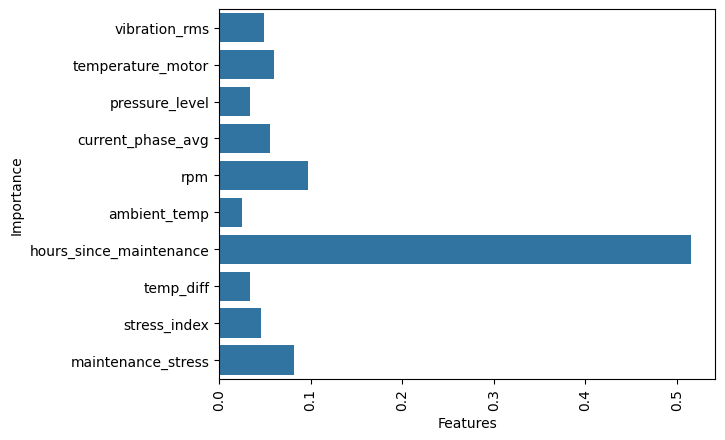

In [48]:
#best features
importances=rfm1.feature_importances_
sns.barplot(y=x.columns,x=importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)

plt.show()